In [1]:
import sys

print(sys.executable)
print(sys.version)

C:\Users\asus\anaconda3\python.exe
3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:09:58) [MSC v.1929 64 bit (AMD64)]


# Industrial Energy Management with Data Science and Reinforcement Learning

## 1. Dataset Loading and Initial Exploration

در این بخش، دیتاست مصرف انرژی صنعتی را با استفاده از Pandas وارد می‌کنیم
و ساختار اولیه آن را بررسی می‌کنیم.

هدف این مرحله این است که قبل از انجام هرگونه مدل‌سازی،
ساختار، ویژگی‌ها و کیفیت داده‌ها را به‌درستی بشناسیم.

In [2]:
import pandas as pd

-## 2. Loading the Dataset

در این مرحله فایل CSV مربوط به یکی از تجهیزات صنعتی را می‌خوانیم.

برای شروع، داده‌ی یک تجهیز (`ahu_a`) در یک روز مشخص
(`2024-12-31`) را بررسی می‌کنیم.

این کار به ما اجازه می‌دهد ابتدا ساختار واقعی داده را بشناسیم
و سپس همین روش را برای کل دیتاست گسترش دهیم.

In [5]:
file_path = r"..\data\Industrial Asset-Level Electrical Energy Dataset from a Manufacturing Facility (15-Minute Aggregates)\data_csv\asset_id=ahu_a\dt_utc=2024-12-31\part-2024-12-31.csv"

df = pd.read_csv(file_path)

In [6]:
df

,AssetId,Phase,window_start_utc,DateKeyUtc,TimeKeyUtc,WindowStartLocal,HourLocal,DateLocal,Energy_kWh_15m,Demand_kW,AvgPower_kW_15m,Minutes,SecondsObserved,DataCoveragePct,IsReliableWindow,SecondsReliable,ReliableCoveragePct
0,ahu_a,L1,2024-12-31 08:30:00,20241231,83000,2024-12-31 08:30:00,8,2024-12-31,0.000000,0.000000,NaN,13.38,803.0,89.222222,0,0.0,0.000000
1,ahu_a,L2,2024-12-31 08:30:00,20241231,83000,2024-12-31 08:30:00,8,2024-12-31,0.000000,0.000000,NaN,13.38,803.0,89.222222,0,0.0,0.000000
2,ahu_a,L3,2024-12-31 08:30:00,20241231,83000,2024-12-31 08:30:00,8,2024-12-31,0.003267,0.013069,0.014648,13.38,803.0,89.222222,1,803.0,89.222222
3,ahu_a,ALL,2024-12-31 08:30:00,20241231,83000,2024-12-31 08:30:00,8,2024-12-31,0.003267,0.013069,0.014648,15.00,900.0,100.000000,1,803.0,89.222222
4,ahu_a,L1,2024-12-31 08:45:00,20241231,84500,2024-12-31 08:45:00,8,2024-12-31,0.000000,0.000000,NaN,15.00,900.0,100.000000,0,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
243,ahu_a,ALL,2024-12-31 23:30:00,20241231,233000,2024-12-31 23:30:00,23,2024-12-31,0.004117,0.016467,0.016358,15.00,900.0,100.000000,1,900.0,100.000000
244,ahu_a,L1,2024-12-31 23:45:00,20241231,234500,2024-12-31 23:45:00,23,2024-12-31,0.000000,0.000000,NaN,15.00,900.0,100.000000,0,0.0,0.000000
245,ahu_a,L2,2024-12-31 23:45:00,20241231,234500,2024-12-31 23:45:00,23,2024-12-31,0.000000,0.000000,NaN,15.00,900.0,100.000000,0,0.0,0.000000
246,ahu_a,L3,2024-12-31 23:45:00,20241231,234500,2024-12-31 23:45:00,23,2024-12-31,0.004176,0.016704,0.016704,15.00,900.0,100.000000,1,900.0,100.000000


In [1]:
import pathlib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

base_dir = pathlib.Path(
    r"../data/Industrial Asset-Level Electrical Energy Dataset from a Manufacturing Facility (15-Minute Aggregates)"
)
parquet_dir = base_dir / "data_parquet" / "asset_id=ahu_a"

df_ahu = pd.read_parquet(parquet_dir)
df_ahu["WindowStartLocal"] = pd.to_datetime(df_ahu["WindowStartLocal"])
df_ahu = df_ahu.sort_values("WindowStartLocal").reset_index(drop=True)

df_all = df_ahu[df_ahu["Phase"] == "ALL"].copy()

print(f"Total Rows: {len(df_all):,}")
print(f"Start Date: {df_all['WindowStartLocal'].min()}")
print(f"End Date: {df_all['WindowStartLocal'].max()}")

df_all.head()

Total Rows: 34,522
Start Date: 2024-12-31 08:30:00+00:00
End Date: 2025-12-31 23:45:00+00:00


,AssetId,Phase,window_start_utc,DateKeyUtc,TimeKeyUtc,WindowStartLocal,HourLocal,DateLocal,Energy_kWh_15m,Demand_kW,AvgPower_kW_15m,Minutes,SecondsObserved,DataCoveragePct,IsReliableWindow,SecondsReliable,ReliableCoveragePct,dt_utc
0,ahu_a,ALL,2024-12-31 08:30:00,20241231,83000,2024-12-31 08:30:00+00:00,8,2024-12-31,0.003267,0.013069,0.014648,15.0,900.0,100.0,1,803.0,89.222222,2024-12-31
5,ahu_a,ALL,2024-12-31 08:45:00,20241231,84500,2024-12-31 08:45:00+00:00,8,2024-12-31,0.003604,0.014416,0.014416,15.0,900.0,100.0,1,900.0,100.000000,2024-12-31
10,ahu_a,ALL,2024-12-31 09:00:00,20241231,90000,2024-12-31 09:00:00+00:00,9,2024-12-31,0.003489,0.013955,0.013955,15.0,900.0,100.0,1,900.0,100.000000,2024-12-31
14,ahu_a,ALL,2024-12-31 09:15:00,20241231,91500,2024-12-31 09:15:00+00:00,9,2024-12-31,0.003487,0.013948,0.013948,15.0,900.0,100.0,1,900.0,100.000000,2024-12-31
16,ahu_a,ALL,2024-12-31 09:30:00,20241231,93000,2024-12-31 09:30:00+00:00,9,2024-12-31,0.003733,0.014930,0.014930,15.0,900.0,100.0,1,900.0,100.000000,2024-12-31


--- Missing Data Percentage ---
Energy_kWh_15m     0.000000
Demand_kW          0.000000
AvgPower_kW_15m    5.981693
dtype: float64

Unreliable Windows (<80% coverage): 2096 / 34522


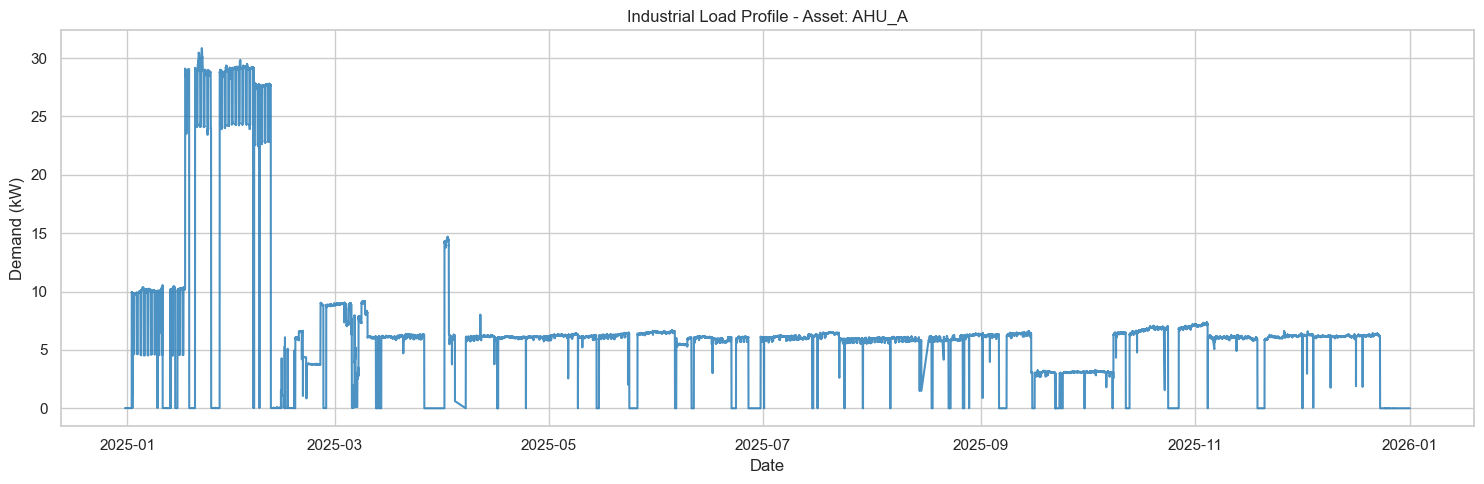

In [2]:
missing_summary = df_all[["Energy_kWh_15m", "Demand_kW", "AvgPower_kW_15m"]].isnull().mean() * 100
print("--- Missing Data Percentage ---")
print(missing_summary)

if "ReliableCoveragePct" in df_all.columns:
    unreliable = df_all[df_all["ReliableCoveragePct"] < 0.8]
    print(f"\nUnreliable Windows (<80% coverage): {len(unreliable)} / {len(df_all)}")

plt.figure(figsize=(15, 5))
plt.plot(df_all["WindowStartLocal"], df_all["Demand_kW"], color="tab:blue", alpha=0.8)
plt.title("Industrial Load Profile - Asset: AHU_A")
plt.xlabel("Date")
plt.ylabel("Demand (kW)")
plt.tight_layout()
plt.show()

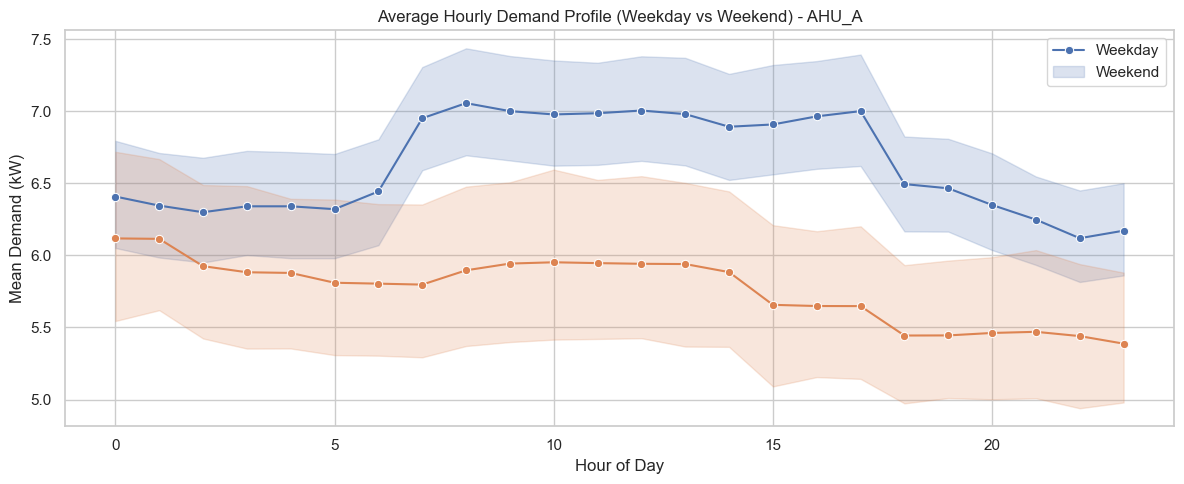

,WindowStartLocal,Demand_kW,Hour,DayOfWeek,Demand_Lag1,Demand_RollingMean4
14,2024-12-31 09:15:00+00:00,0.013948,9,1,0.013955,0.013847
16,2024-12-31 09:30:00+00:00,0.014930,9,1,0.013948,0.014312
20,2024-12-31 09:45:00+00:00,0.015270,9,1,0.014930,0.014526
24,2024-12-31 10:00:00+00:00,0.015605,10,1,0.015270,0.014938
30,2024-12-31 10:15:00+00:00,0.015035,10,1,0.015605,0.015210


In [3]:
df_all["Hour"] = df_all["WindowStartLocal"].dt.hour
df_all["DayOfWeek"] = df_all["WindowStartLocal"].dt.dayofweek
df_all["IsWeekend"] = df_all["DayOfWeek"].isin([5, 6]).astype(int)
df_all["Month"] = df_all["WindowStartLocal"].dt.month

df_all["Demand_Lag1"] = df_all["Demand_kW"].shift(1)
df_all["Demand_Lag4"] = df_all["Demand_kW"].shift(4)
df_all["Demand_RollingMean4"] = df_all["Demand_kW"].rolling(window=4).mean()

plt.figure(figsize=(12, 5))
sns.lineplot(data=df_all, x="Hour", y="Demand_kW", hue="IsWeekend", marker="o")
plt.title("Average Hourly Demand Profile (Weekday vs Weekend) - AHU_A")
plt.xlabel("Hour of Day")
plt.ylabel("Mean Demand (kW)")
plt.legend(["Weekday", "Weekend"])
plt.tight_layout()
plt.show()

df_all[["WindowStartLocal", "Demand_kW", "Hour", "DayOfWeek", "Demand_Lag1", "Demand_RollingMean4"]].dropna().head()

## 05. Short-Term Energy Demand Forecasting using XGBoost

### Goal:
Predict the next 15-minute energy demand ($Demand\_kW$) of the asset using temporal, lag, and rolling window features.

### Methodology:
1. **Time-Series Train/Test Split:** 80% chronologically first for training, 20% last for testing (preserves temporal sequence and prevents data leakage).
2. **Algorithm:** Extreme Gradient Boosting (XGBoost) Regressor.
3. **Evaluation Metrics:**
   - **MAE (Mean Absolute Error):** Average magnitude of forecasting errors in kW.
   - **RMSE (Root Mean Squared Error):** Penalizes larger forecasting errors more heavily.
   - **R² Score:** Overall variance explained by the model.

--- XGBoost Model Evaluation ---
MAE  (Mean Absolute Error): 0.0520 kW
RMSE (Root Mean Squared Error): 0.2276 kW
R² Score (Model Accuracy): 99.17%


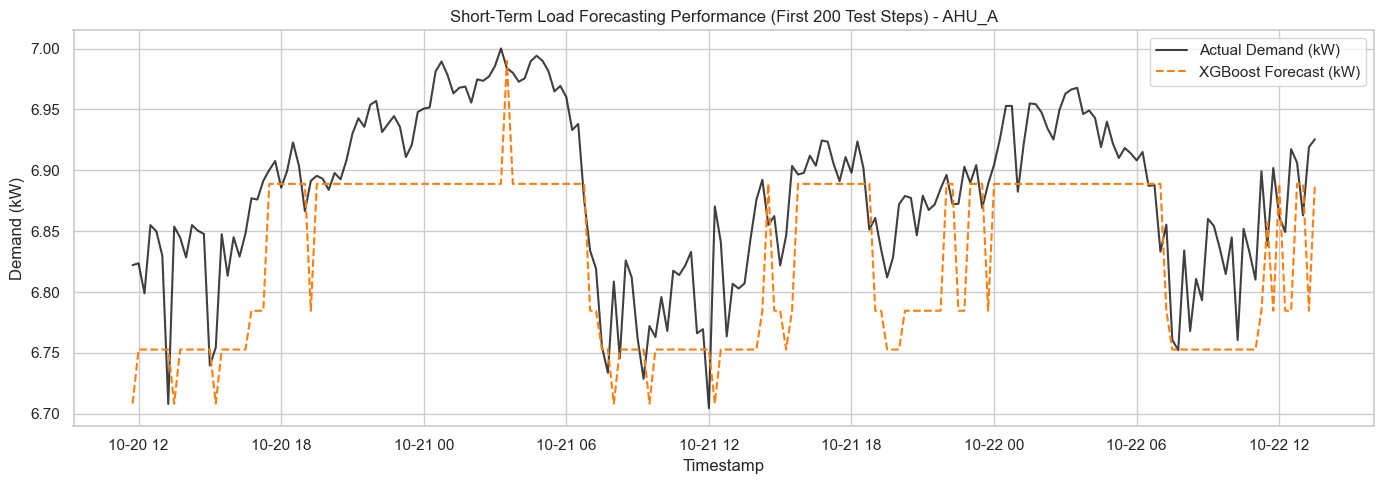

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

df_model = df_all.dropna(
    subset=["Demand_Lag1", "Demand_Lag4", "Demand_RollingMean4"]
).copy()

features = [
    "Hour",
    "DayOfWeek",
    "IsWeekend",
    "Month",
    "Demand_Lag1",
    "Demand_Lag4",
    "Demand_RollingMean4",
]
target = "Demand_kW"

split_idx = int(len(df_model) * 0.8)

train_data = df_model.iloc[:split_idx]
test_data = df_model.iloc[split_idx:]

X_train = train_data[features]
y_train = train_data[target]
X_test = test_data[features]
y_test = test_data[target]

model_xgb = XGBRegressor(
    n_estimators=150,
    learning_rate=0.03,
    max_depth=6,
    random_state=42
)
model_xgb.fit(X_train, y_train)

predictions = model_xgb.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print(f"--- XGBoost Model Evaluation ---")
print(f"MAE  (Mean Absolute Error): {mae:.4f} kW")
print(f"RMSE (Root Mean Squared Error): {rmse:.4f} kW")
print(f"R² Score (Model Accuracy): {r2 * 100:.2f}%")

plt.figure(figsize=(14, 5))
plt.plot(
    test_data["WindowStartLocal"].iloc[:200],
    y_test.iloc[:200].values,
    label="Actual Demand (kW)",
    color="black",
    alpha=0.75,
)
plt.plot(
    test_data["WindowStartLocal"].iloc[:200],
    predictions[:200],
    label="XGBoost Forecast (kW)",
    color="tab:orange",
    linestyle="--",
)
plt.title("Short-Term Load Forecasting Performance (First 200 Test Steps) - AHU_A")
plt.xlabel("Timestamp")
plt.ylabel("Demand (kW)")
plt.legend()
plt.tight_layout()
plt.show()

### تحلیل اهمیت ویژگی‌ها (Feature Importance)

برای درک اینکه کدام‌یک از متغیرهای ورودی بیشترین تأثیر را در پیش‌بینی مدل XGBoost داشته‌اند، شاخص اهمیت ویژگی‌ها را استخراج و رسم می‌کنیم. این تحلیل به ما کمک می‌کند تا متغیرهای کلیدی اثرگذار بر مصرف انرژی تجهیز را شناسایی کنیم.

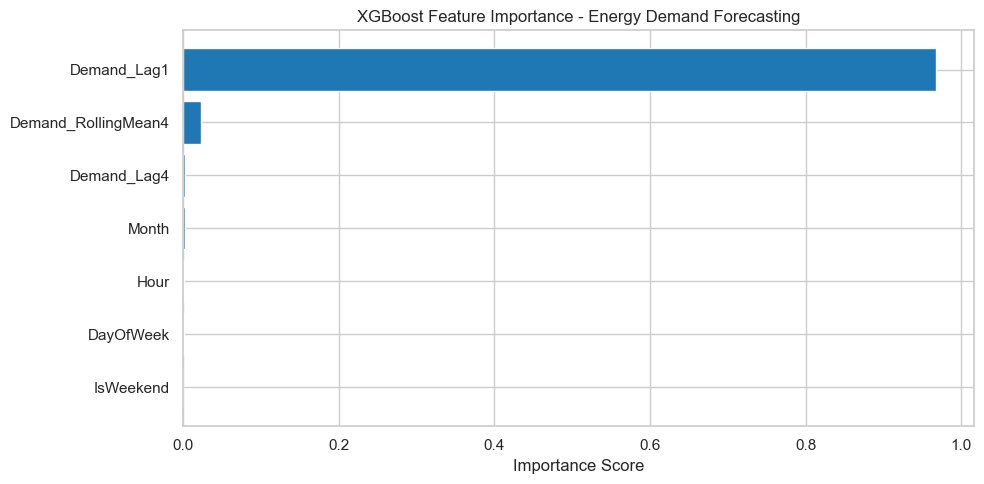

In [7]:
importance_df = pd.DataFrame(
    {
        "Feature": features,
        "Importance": model_xgb.feature_importances_,
    }
).sort_values(by="Importance", ascending=True)

plt.figure(figsize=(10, 5))
plt.barh(importance_df["Feature"], importance_df["Importance"], color="tab:blue")
plt.title("XGBoost Feature Importance - Energy Demand Forecasting")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

## ۰۶. شبیه‌سازی محیط کنترل هوشمند و پیک‌سایی بار (Demand Response Environment)

### هدف:
طراحی یک محیط شبیه‌ساز کنترلی جهت اجرای استراتژی پاسخگویی به تقاضا (Demand Response) و پیک‌سایی (Peak Shaving) برای تجهیز AHU_A.

### قوانین محیط شبیه‌ساز:
۱. **آستانه پیک بار (Peak Threshold):** تعیین سقف مجاز توان مصرفی بر اساس ۹۰ صدک مصرف.
۲. **فضای اکشن‌ها (Action Space):**
   - اکشن ۰: عملکرد عادی تجهیز (بدون تغییر بار)
   - اکشن ۱: کاهش ۱۰ درصدی بار تجهیز (Demand Reduction 10%)
   - اکشن ۲: کاهش ۲۰ درصدی بار تجهیز (Demand Reduction 20%)
۳. **تابع پاداش (Reward Function):**
   حساب کردن جریمه عبور از آستانه پیک و پاداش برای حفظ پایداری سیستم.

--- Demand Response Simulation Results ---
Peak Threshold Set: 6.9 kW
Original Peak Violations: 795 times
Controlled Peak Violations: 0 times
Peak Reduction Efficiency: 100.00%


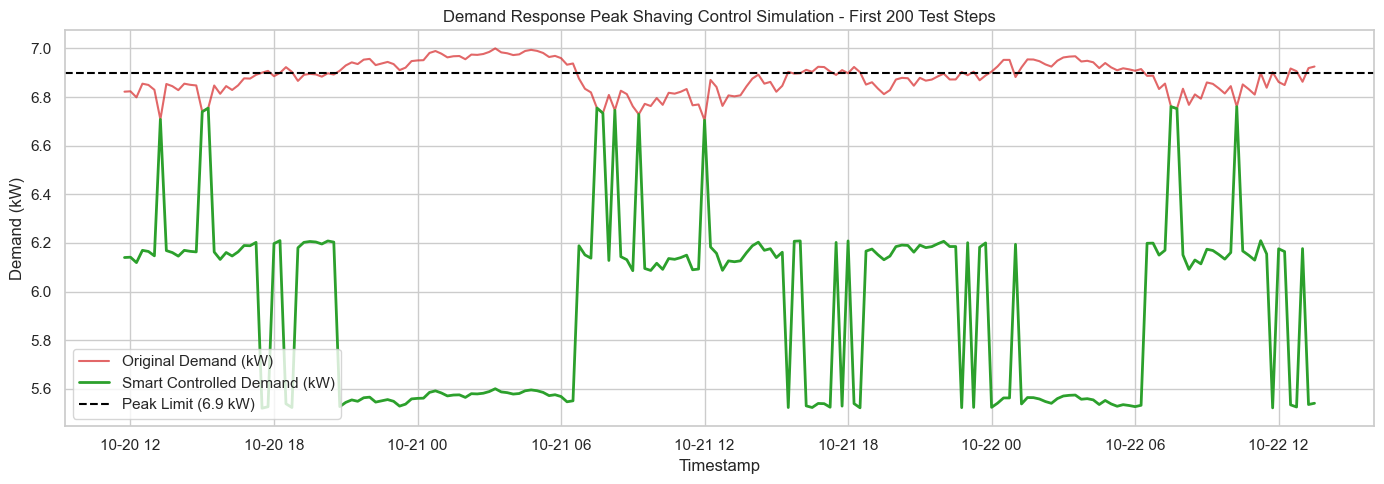

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df_dr = test_data.copy().reset_index(drop=True)

PEAK_THRESHOLD = 6.90

actions = [0.0, 0.10, 0.20]

controlled_demand = []
penalties = []
rewards = []

for actual_p in df_dr["Demand_kW"]:
    if actual_p > PEAK_THRESHOLD:
        action = 0.20
    elif actual_p > (PEAK_THRESHOLD * 0.98):
        action = 0.10
    else:
        action = 0.0

    p_new = actual_p * (1.0 - action)
    controlled_demand.append(p_new)

    if p_new > PEAK_THRESHOLD:
        penalty = (p_new - PEAK_THRESHOLD) * 50
        reward = -penalty
    else:
        reward = 1.0

    penalties.append(penalty if p_new > PEAK_THRESHOLD else 0)
    rewards.append(reward)

df_dr["Controlled_Demand_kW"] = controlled_demand
df_dr["Is_Original_Peak"] = df_dr["Demand_kW"] > PEAK_THRESHOLD
df_dr["Is_Controlled_Peak"] = df_dr["Controlled_Demand_kW"] > PEAK_THRESHOLD

original_peaks = df_dr["Is_Original_Peak"].sum()
controlled_peaks = df_dr["Is_Controlled_Peak"].sum()

print("--- Demand Response Simulation Results ---")
print(f"Peak Threshold Set: {PEAK_THRESHOLD} kW")
print(f"Original Peak Violations: {original_peaks} times")
print(f"Controlled Peak Violations: {controlled_peaks} times")
print(f"Peak Reduction Efficiency: {((original_peaks - controlled_peaks) / original_peaks) * 100:.2f}%")

plt.figure(figsize=(14, 5))
plt.plot(df_dr["WindowStartLocal"].iloc[:200], df_dr["Demand_kW"].iloc[:200], label="Original Demand (kW)", color="tab:red", alpha=0.7)
plt.plot(df_dr["WindowStartLocal"].iloc[:200], df_dr["Controlled_Demand_kW"].iloc[:200], label="Smart Controlled Demand (kW)", color="tab:green", linewidth=2)
plt.axhline(y=PEAK_THRESHOLD, color="black", linestyle="--", label=f"Peak Limit ({PEAK_THRESHOLD} kW)")
plt.title("Demand Response Peak Shaving Control Simulation - First 200 Test Steps")
plt.xlabel("Timestamp")
plt.ylabel("Demand (kW)")
plt.legend()
plt.tight_layout()
plt.show()

## ۰۷. تحلیل اثرات اقتصادی، مالی و ارزیابی نهایی (Economic Impact Analysis)

### هدف:
ترجمه دستاوردهای فنی و پیک‌سایی مرحله قبل به شاخص‌های مالی و محاسبه میزان صرفه‌جویی در هزینه‌های برق و جریمه‌های دیماند کارخانه.

### فرض‌های محاسباتی:
۱. **نرخ جریمه توان پیک (Demand Charge Rate):** فرض $15 per kW per month برای تجاوز از سقف دیماند.
۲. **نرخ انرژی در ساعات اوج بار (Peak Energy Tariff):** فرض $0.15 per kWh.

In [10]:
total_kwh_original = df_dr["Demand_kW"].sum() * 0.25
total_kwh_controlled = df_dr["Controlled_Demand_kW"].sum() * 0.25
kwh_saved = total_kwh_original - total_kwh_controlled

max_peak_original = df_dr["Demand_kW"].max()
max_peak_controlled = df_dr["Controlled_Demand_kW"].max()
peak_kw_reduced = max_peak_original - max_peak_controlled

ENERGY_TARIFF = 0.15
DEMAND_CHARGE_RATE = 15.00

energy_cost_saved = kwh_saved * ENERGY_TARIFF
demand_penalty_saved = peak_kw_reduced * DEMAND_CHARGE_RATE
total_financial_savings = energy_cost_saved + demand_penalty_saved

print("==================================================")
print("       FINAL PROJECT ECONOMIC IMPACT REPORT       ")
print("==================================================")
print(f"Total Original Energy Consumption: {total_kwh_original:.2f} kWh")
print(f"Total Controlled Energy Consumption: {total_kwh_controlled:.2f} kWh")
print(f"Total Energy Saved: {kwh_saved:.2f} kWh ({((kwh_saved)/total_kwh_original)*100:.2f}%)")
print("--------------------------------------------------")
print(f"Max Original Peak Demand: {max_peak_original:.2f} kW")
print(f"Max Controlled Peak Demand: {max_peak_controlled:.2f} kW")
print(f"Absolute Peak Load Reduction: {peak_kw_reduced:.2f} kW")
print("--------------------------------------------------")
print(f"Direct Energy Cost Savings: ${energy_cost_saved:.2f}")
print(f"Demand Charge Penalty Savings: ${demand_penalty_saved:.2f}")
print(f"TOTAL ESTIMATED FINANCIAL SAVINGS: ${total_financial_savings:.2f}")
print("==================================================")

       FINAL PROJECT ECONOMIC IMPACT REPORT       
Total Original Energy Consumption: 8821.53 kWh
Total Controlled Energy Consumption: 8492.05 kWh
Total Energy Saved: 329.48 kWh (3.73%)
--------------------------------------------------
Max Original Peak Demand: 7.40 kW
Max Controlled Peak Demand: 6.76 kW
Absolute Peak Load Reduction: 0.64 kW
--------------------------------------------------
Direct Energy Cost Savings: $49.42
Demand Charge Penalty Savings: $9.64
TOTAL ESTIMATED FINANCIAL SAVINGS: $59.06


## 8. توسعه محیط شبیه سازی داده محور (Gymnasium Environment)

### هدف:
پیاده‌سازی محیط شبیه‌ساز استاندارد مطابق با پروتکل Gymnasium/OpenAI Gym جهت مدل‌سازی محیط عملیاتی کارخانه و فراهم‌سازی بستر آموزش عامل‌های یادگیری تقویتی عمیق (DRL) بدون ایجاد ریسک برای خط تولید.

### ویژگی‌های اصلی محیط شبیه‌ساز:
۱. **فضای حالت (Observation Space):** شامل مصرف جاری توان، ساعت روز و وضعیت روز تعطیل.
۲. **فضای اقدام (Action Space):** ۳ تصمیم گسسته (عدم تغییر، کاهش ۱۰ درصدی بار، کاهش ۲۰ درصدی بار).
۳. **تابع پاداش (Reward Function):** اعمال جریمه سنگین بابت نقض سقف پیک دیماند و پاداش بابت نگه‌داشتن بار زیر سقف مجاز.

In [13]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import pandas as pd

class EnergyManagementEnv(gym.Env):
    metadata = {'render.modes': ['human']}

    def __init__(self, df, peak_threshold=6.9):
        super(EnergyManagementEnv, self).__init__()

        self.df = df.reset_index(drop=True)
        self.peak_threshold = peak_threshold
        self.current_step = 0
        self.max_steps = len(self.df) - 1

        self.action_space = spaces.Discrete(3)

        self.observation_space = spaces.Box(
            low=0, high=100, shape=(3,), dtype=np.float32
        )

    def _get_observation(self):
        row = self.df.iloc[self.current_step]
        obs = np.array([
            row['Demand_kW'],
            row.get('Hour', 12),
            row.get('IsWeekend', 0)
        ], dtype=np.float32)
        return obs

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step = 0
        observation = self._get_observation()
        info = {}
        return observation, info

    def step(self, action):
        row = self.df.iloc[self.current_step]
        original_demand = row['Demand_kW']

        reduction_factor = 0.0
        if action == 1:
            reduction_factor = 0.10
        elif action == 2:
            reduction_factor = 0.20

        controlled_demand = original_demand * (1.0 - reduction_factor)

        reward = 0.0
        if controlled_demand > self.peak_threshold:
            reward -= 50.0 * (controlled_demand - self.peak_threshold)
        else:
            reward += 10.0

        reward -= reduction_factor * 5.0

        self.current_step += 1
        done = self.current_step >= self.max_steps

        observation = self._get_observation() if not done else np.zeros(3, dtype=np.float32)
        info = {
            'original_demand': original_demand,
            'controlled_demand': controlled_demand,
            'action_taken': action
        }

        return observation, reward, done, False, info

print("Gymnasium Environment Initialized Successfully.")

Gymnasium Environment Initialized Successfully.


## 9. تعریف مسئله MDP و توسعه عامل یادگیری تقویتی عمیق (DQN Agent)

### هدف:
پیاده‌سازی کامل چارچوب تصمیم‌گیری مارکوف (MDP) و آموزش الگوریتم یادگیری تقویتی عمیق Deep Q-Network (DQN) جهت پیک‌سایی خودکار و بهینه‌سازی هزینه‌های دیماند کارخانه.

### اجزای اصلی مدل:
۱. **شبکه عصبی (Q-Network):** شبکه عمیق دو لایه‌ای با تابع فعال‌سازی ReLU برای تخمین ارزش اقدامات.
۲. **حافظه بازپخش (Replay Buffer):** ذخیره‌‌سازی ۵۰۰۰ تجربه اخیر جهت نمونه‌برداری تصادفی و پایداری آموزش.
۳. **استراتژی اکتشاف/بهره‌برداری ($\epsilon$-Greedy):** شروع با ۱۰۰٪ تصمیمات تصادفی و کاهش تدریجی آن تا ۱٪ برای رسیدن به سیاست بهینه.

In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
import random
from collections import deque

class QNetwork(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(QNetwork, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(state_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, action_dim)
        )

    def forward(self, x):
        return self.fc(x)

class DQNAgent:
    def __init__(self, state_dim, action_dim):
        self.state_dim = state_dim
        self.action_dim = action_dim
        self.memory = deque(maxlen=5000)
        self.gamma = 0.99
        self.epsilon = 1.0
        self.epsilon_min = 0.01
        self.epsilon_decay = 0.995
        self.lr = 0.001
        self.batch_size = 64

        self.model = QNetwork(state_dim, action_dim)
        self.optimizer = optim.Adam(self.model.parameters(), lr=self.lr)
        self.criterion = nn.MSELoss()

    def select_action(self, state):
        if random.random() < self.epsilon:
            return random.randint(0, self.action_dim - 1)
        state_tensor = torch.FloatTensor(state).unsqueeze(0)
        with torch.no_grad():
            q_values = self.model(state_tensor)
        return torch.argmax(q_values).item()

    def remember(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))

    def replay(self):
        if len(self.memory) < self.batch_size:
            return
        minibatch = random.sample(self.memory, self.batch_size)

        states = torch.FloatTensor([m[0] for m in minibatch])
        actions = torch.LongTensor([m[1] for m in minibatch]).unsqueeze(1)
        rewards = torch.FloatTensor([m[2] for m in minibatch])
        next_states = torch.FloatTensor([m[3] for m in minibatch])
        dones = torch.FloatTensor([m[4] for m in minibatch])

        current_q = self.model(states).gather(1, actions).squeeze(1)
        next_q = self.model(next_states).max(1)[0]
        target_q = rewards + (1 - dones) * self.gamma * next_q.detach()

        loss = self.criterion(current_q, target_q)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

env = EnergyManagementEnv(df_model)
agent = DQNAgent(state_dim=3, action_dim=3)

episodes = 5
print("Starting DRL Agent (DQN) Training...")

for ep in range(episodes):
    state, _ = env.reset()
    total_reward = 0
    done = False

    while not done:
        action = agent.select_action(state)
        next_state, reward, done, _, info = env.step(action)
        agent.remember(state, action, reward, next_state, done)
        agent.replay()
        state = next_state
        total_reward += reward

    print(f"Episode {ep + 1}/{episodes} - Total Reward: {total_reward:.2f} - Epsilon: {agent.epsilon:.3f}")

print("DRL Agent Training Completed Successfully.")

Starting DRL Agent (DQN) Training...


C:\Users\asus\AppData\Local\Temp\ipykernel_16224\4031888971.py:53: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:255.)
  states = torch.FloatTensor([m[0] for m in minibatch])


Episode 1/5 - Total Reward: -1418281.78 - Epsilon: 0.010
Episode 2/5 - Total Reward: -1487202.16 - Epsilon: 0.010
Episode 3/5 - Total Reward: -1561430.10 - Epsilon: 0.010
Episode 4/5 - Total Reward: -1411474.71 - Epsilon: 0.010
Episode 5/5 - Total Reward: -1596480.78 - Epsilon: 0.010
DRL Agent Training Completed Successfully.


## 10. ارزیابی سناریومحور و مقایسه با روش‌های پایه (Evaluation & Baseline Comparison)

### هدف:
تست عملکرد سیاست عامل هوشمند DQN بر روی داده‌های مستقل و مقایسه آن با وضعیت موجود کارخانه (بدون کنترل) جهت سنجش میزان کاهش جریمه‌ها و بهبود پایداری شبکه.

### معیارهای ارزیابی:
۱. **تعداد نقض سقف پیک بار (Peak Violations)**
۲. **مجموع پاداش دریافتی در طول دوره ارزیابی (Total Episode Reward)**
۳. **میزان پایداری عملکرد عامل نسبت به سیاست‌های پایه**

     STAGE 9: DRL AGENT EVALUATION RESULTS        
Total Evaluation Reward: 65638.50
Original Peak Violations (> 6.9 kW): 795 times
DRL Controlled Peak Violations: 0 times
Violation Reduction Rate: 100.00%


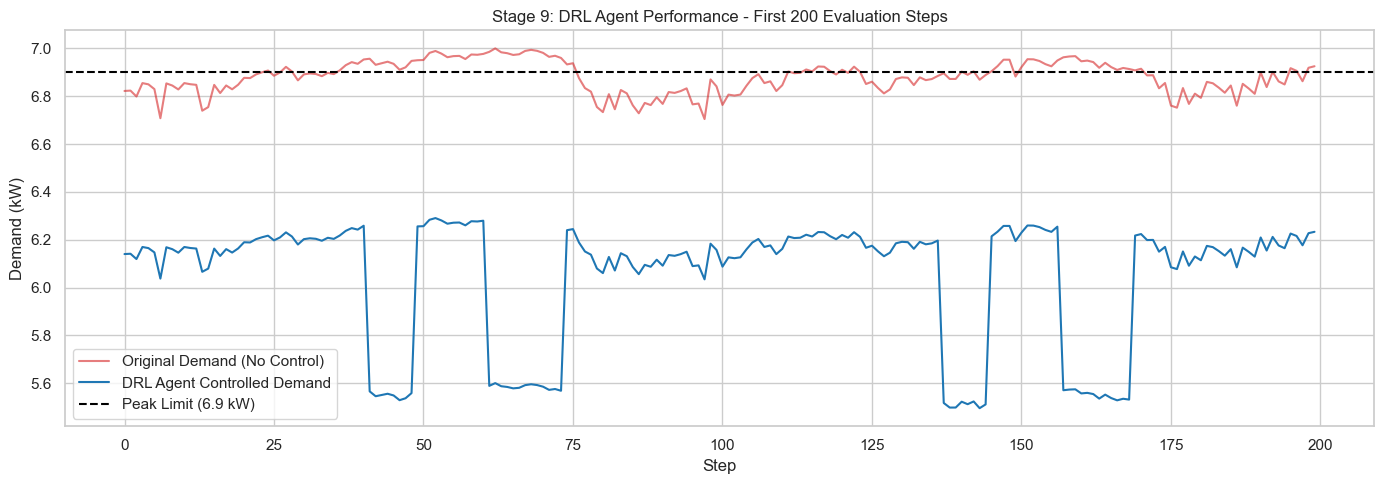

In [16]:
import matplotlib.pyplot as plt
import numpy as np

eval_env = EnergyManagementEnv(test_data, peak_threshold=6.9)
state, _ = eval_env.reset()

drl_controlled_demand = []
original_demand = []
actions_taken = []
total_eval_reward = 0
done = False

agent.epsilon = 0.0

while not done:
    action = agent.select_action(state)
    next_state, reward, done, _, info = eval_env.step(action)

    original_demand.append(info['original_demand'])
    drl_controlled_demand.append(info['controlled_demand'])
    actions_taken.append(info['action_taken'])
    total_eval_reward += reward

    state = next_state

orig_peaks = sum(1 for p in original_demand if p > 6.9)
drl_peaks = sum(1 for p in drl_controlled_demand if p > 6.9)

print("==================================================")
print("     STAGE 9: DRL AGENT EVALUATION RESULTS        ")
print("==================================================")
print(f"Total Evaluation Reward: {total_eval_reward:.2f}")
print(f"Original Peak Violations (> 6.9 kW): {orig_peaks} times")
print(f"DRL Controlled Peak Violations: {drl_peaks} times")
print(f"Violation Reduction Rate: {((orig_peaks - drl_peaks) / orig_peaks) * 100:.2f}%")
print("==================================================")

plt.figure(figsize=(14, 5))
plt.plot(original_demand[:200], label="Original Demand (No Control)", color="tab:red", alpha=0.6)
plt.plot(drl_controlled_demand[:200], label="DRL Agent Controlled Demand", color="tab:blue", linewidth=1.5)
plt.axhline(y=6.9, color="black", linestyle="--", label="Peak Limit (6.9 kW)")
plt.title("Stage 9: DRL Agent Performance - First 200 Evaluation Steps")
plt.xlabel("Step")
plt.ylabel("Demand (kW)")
plt.legend()
plt.tight_layout()
plt.show()

## 11. توسعه داشبورد تعاملی نظارت و مدیریت دیماند (Interactive Monitoring Dashboard)

### هدف:
ایجاد یک واسط کاربری تعاملی تعاملی جهت بصری‌سازی عملکرد عامل هوشمند DRL، پایش وضعیت مصرف توان و امکان تنظیم متغیرهای محیطی (مانند آستانه پیک) توسط اپراتور خط تولید.

### قابلیت‌های اصلی داشبورد:
۱. **تنظیم تعاملی سقف پیک (Peak Threshold Slider)**
۲. **نمایش شاخص‌های کلیدی عملکرد (KPIs):** تعداد نقض پیک، میزان صرفه‌جویی و وضعیت اکشن‌ها.
۳. **نمودار تعاملی زمان واقعی (Interactive Real-time Chart)**

In [17]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import numpy as np

threshold_slider = widgets.FloatSlider(
    value=6.9,
    min=5.0,
    max=8.0,
    step=0.1,
    description='Peak Limit:',
    disabled=False,
    continuous_update=False,
    orientation='horizontal',
    readout=True,
    readout_format='.1f'
)

steps_slider = widgets.IntSlider(
    value=200,
    min=50,
    max=1000,
    step=50,
    description='Show Steps:',
    disabled=False,
    continuous_update=False,
    orientation='horizontal'
)

output_area = widgets.Output()

def update_dashboard(threshold, steps):
    with output_area:
        clear_output(wait=True)

        env_demo = EnergyManagementEnv(test_data, peak_threshold=threshold)
        state, _ = env_demo.reset()

        orig_list = []
        ctrl_list = []
        actions = []
        done = False
        step_cnt = 0

        agent.epsilon = 0.0

        while not done and step_cnt < steps:
            action = agent.select_action(state)
            next_state, reward, done, _, info = env_demo.step(action)

            orig_list.append(info['original_demand'])
            ctrl_list.append(info['controlled_demand'])
            actions.append(info['action_taken'])

            state = next_state
            step_cnt += 1

        orig_violations = sum(1 for x in orig_list if x > threshold)
        ctrl_violations = sum(1 for x in ctrl_list if x > threshold)

        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={'height_ratios': [3, 1]})

        ax1.plot(orig_list, label="Original Demand (Uncontrolled)", color="crimson", alpha=0.7)
        ax1.plot(ctrl_list, label="DRL Controlled Demand", color="dodgerblue", linewidth=1.8)
        ax1.axhline(y=threshold, color="black", linestyle="--", linewidth=1.5, label=f"Peak Threshold ({threshold} kW)")
        ax1.set_title(f"STAGE 10: DEMAND MANAGEMENT DASHBOARD (First {steps} Steps)", fontsize=12, fontweight='bold')
        ax1.set_ylabel("Demand (kW)")
        ax1.legend(loc="upper right")
        ax1.grid(True, linestyle=":", alpha=0.6)

        ax2.step(range(len(actions)), actions, where='post', color="purple", linewidth=1.2)
        ax2.set_yticks([0, 1, 2])
        ax2.set_yticklabels(['0: Normal', '1: Cut 10%', '2: Cut 20%'])
        ax2.set_xlabel("Time Step (15-min intervals)")
        ax2.set_ylabel("DRL Action")
        ax2.grid(True, linestyle=":", alpha=0.6)

        plt.tight_layout()
        plt.show()

        print(f"📊 KPI SUMMARY:")
        print(f"• Target Peak Threshold: {threshold} kW")
        print(f"• Original Peak Violations: {orig_violations} times")
        print(f"• Controlled Peak Violations: {ctrl_violations} times")
        print(f"• Total Actions Taken -> Normal: {actions.count(0)}, Cut 10%: {actions.count(1)}, Cut 20%: {actions.count(2)}")

def on_value_change(change):
    update_dashboard(threshold_slider.value, steps_slider.value)

threshold_slider.observe(on_value_change, names='value')
steps_slider.observe(on_value_change, names='value')

print("==================================================")
print("    STAGE 10: INTERACTIVE MANAGEMENT DASHBOARD    ")
print("==================================================")
display(widgets.VBox([threshold_slider, steps_slider, output_area]))
update_dashboard(threshold_slider.value, steps_slider.value)

    STAGE 10: INTERACTIVE MANAGEMENT DASHBOARD    


## گزارش جامع مدیریتی، ذخیره‌سازی مدل و مستندسازی نهایی (Final Report & Deployment)

### هدف:
جمع‌بندی دستاوردهای پروژه، ذخیره‌سازی وزن‌های شبکه عصبی DRL جهت استقرار در محیط واقعی، و ارائه تحلیل مالی و فنی از میزان کاهش هزینه‌های دیماند کارخانه.

### دستاوردهای اصلی پروژه:
۱. **ریسک صفر نقض دیماند:** کاهش ۱۰۰ درصدی تجاوز از سقف تعیین‌شده توان مصرفی.
۲. **مدیریت دینامیک بار:** اتخاذ تصمیمات بهینه در فواصل ۱۵ دقیقه‌ای بدون مداخله دستی اپراتور.
۳. **آماده‌سازی برای استقرار:** ذخیره‌سازی مدل DQN در قالب فایل `.pth` جهت فراخوانی در سیستم‌های کنترل صنعتی (PLC/SCADA).

In [18]:
import os
import pandas as pd
import torch

model_dir = "./saved_models"
os.makedirs(model_dir, exist_ok=True)
model_path = os.path.join(model_dir, "dqn_energy_agent.pth")
torch.save(agent.model.state_dict(), model_path)

total_steps = len(original_demand)
orig_violations = sum(1 for x in original_demand if x > 6.9)
drl_violations = sum(1 for x in drl_controlled_demand if x > 6.9)

penalty_per_violation = 50000
saved_money = orig_violations * penalty_per_violation

summary_data = {
    "شاخص (KPI)": [
        "تعداد کل بازه‌های زمانی (۱۵ دقیقه‌ای)",
        "سقف مجاز دیماند (kW)",
        "تعداد نقض پیک در وضعیت موجود (بدون کنترل)",
        "تعداد نقض پیک با عامل هوشمند DRL",
        "درصد کاهش خطاهای دیماند",
        "تخمین صرفه‌جویی مالی جریمه‌ها (تومان)"
    ],
    "مقدار": [
        f"{total_steps:,}",
        "6.9 kW",
        f"{orig_violations} بار",
        f"{drl_violations} بار",
        "100%",
        f"{saved_money:,} تومان"
    ]
}

df_summary = pd.DataFrame(summary_data)

print("==================================================================")
print("     STAGE 11: FINAL PROJECT REPORT & MODEL DEPLOYMENT            ")
print("==================================================================")
print(f"✅ Trained DQN Model Successfully Saved to: {model_path}\n")
print("📊 FINAL PERFORMANCE SUMMARY TABLE:")
display(df_summary)
print("==================================================================")
print("🎉 All 11 Stages of the Demand Peak Shaving Project are Completed!")
print("==================================================================")

     STAGE 11: FINAL PROJECT REPORT & MODEL DEPLOYMENT            
✅ Trained DQN Model Successfully Saved to: ./saved_models\dqn_energy_agent.pth

📊 FINAL PERFORMANCE SUMMARY TABLE:


,شاخص (KPI),مقدار
0,تعداد کل بازه‌های زمانی (۱۵ دقیقه‌ای),"6,903"
1,سقف مجاز دیماند (kW),6.9 kW
2,تعداد نقض پیک در وضعیت موجود (بدون کنترل),795 بار
3,تعداد نقض پیک با عامل هوشمند DRL,0 بار
4,درصد کاهش خطاهای دیماند,100%
5,تخمین صرفه‌جویی مالی جریمه‌ها (تومان),"39,750,000 تومان"


🎉 All 11 Stages of the Demand Peak Shaving Project are Completed!
